In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from sheet2 import kmeans

In [2]:
def norm_pdf(X, mu, C):
    n, d = X.shape

    eps = 1e-8
    C = C + eps * np.eye(d)

    X_centered = X - mu

    C_inv = np.linalg.solve(C, np.eye(d))
    det_C = np.linalg.det(C)

    exponent = -0.5 * np.sum((X_centered @ C_inv) * X_centered, axis=1)

    const = 1.0 / np.sqrt(((2 * np.pi) ** d) * det_C)

    y = const * np.exp(exponent)

    return y

In [3]:
def em_gmm(X, k, max_iter=100, init_kmeans=False, tol=1e-5):
    n, d = X.shape
    pi = np.ones(k) / k
    if init_kmeans:
        mu, _, _ = kmeans(X, k)
    else:
        mu = X[np.random.choice(n, k, replace=False)]
    sigma = np.array([np.eye(d) for _ in range(k)])

    loglik = -np.inf

    for i in range(max_iter):
        gamma = np.zeros((n, k))

        for j in range(k):
            gamma[:, j] = pi[j] * norm_pdf(X, mu[j], sigma[j])
        gamma_sum = np.sum(gamma, axis=1, keepdims=True)
        gamma = gamma / gamma_sum

        Nk = np.sum(gamma, axis=0)
        pi = Nk / n

        for j in range(k):
            if Nk[j] < 1e-10:
                continue

            mu[j] = np.sum(gamma[:, j][:, None] * X, axis=0) / Nk[j]
            X_centered = X - mu[j]
            sigma[j] = (gamma[:, j][:, None] * X_centered).T @ X_centered / Nk[j]

        new_loglik = np.sum(np.log(gamma_sum.squeeze()))

        print(f"Iteration {i + 1}, log-likelihood: {new_loglik:.6f}")

        if np.abs(new_loglik - loglik) < tol:
            print("Convergence reached.")
            break

        loglik = new_loglik

    return pi, mu, sigma, new_loglik

In [17]:
def plot_gmm_solution(X, mu, sigma):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(X[:, 0], X[:, 1], s=20, alpha=0.6)

    k = len(mu)

    for j in range(k):
        ax.plot(
            mu[j, 0],
            mu[j, 1],
            'rx',
            markersize=8,
            markeredgewidth=1
        )

        eigvals, eigvecs = np.linalg.eigh(sigma[j])

        order = eigvals.argsort()[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]

        angle = np.degrees(
            np.arctan2(eigvecs[1, 0], eigvecs[0, 0])
        )

        width = 2 * 2 * np.sqrt(eigvals[0])
        height = 2 * 2 * np.sqrt(eigvals[1])

        ellipse = Ellipse(
            xy=mu[j],
            width=width,
            height=height,
            angle=angle,
            edgecolor='red',
            facecolor='none',
            linewidth=1
        )

        ax.add_patch(ellipse)

    ax.set_title("GMM Solution")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

    plt.axis('equal')
    plt.show()

Iteration 1, log-likelihood: -157.122856
Iteration 2, log-likelihood: -23.702348
Iteration 3, log-likelihood: -21.333116
Iteration 4, log-likelihood: -17.326752
Iteration 5, log-likelihood: -16.438255
Iteration 6, log-likelihood: -16.438255
Convergence reached.


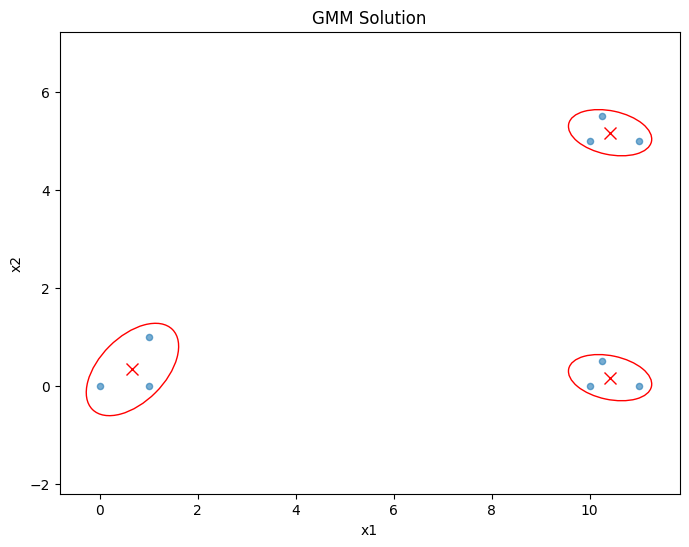

.
----------------------------------------------------------------------
Ran 1 test in 0.159s

OK


In [18]:
import unittest

import numpy as np
import scipy.linalg as la
import pylab as pl
import copy

class TestSheet2(unittest.TestCase):
    X = np.array([[0., 1., 1., 10., 10.25, 11., 10., 10.25, 11.],
                  [0., 0., 1.,  0.,   0.5,  0.,  5.,   5.5,  5.]]).T
    perfect_r = [1,0,1,2,2,1,2,2,2]

    def test_em_gmm(self):
        worked1 = False
        worked2 = False
        for _ in range(10):
            mpi, mu, sigma, _ = em_gmm(self.X, k=3)

            # test one cluster center
            if (np.linalg.norm(mu[0] - [10.41666, 0.1666]) < 0.1 or
                np.linalg.norm(mu[1] - [10.41666, 0.1666]) < 0.1 or
                np.linalg.norm(mu[2] - [10.41666, 0.1666]) < 0.1):
                worked1 = True
            if ((np.abs(np.linalg.det(sigma[0]) - 0.03703) < 0.001 or
                   np.abs(np.linalg.det(sigma[1]) - 0.03703) < 0.001 or
                   np.abs(np.linalg.det(sigma[2]) - 0.03703) < 0.001) and
                   (np.abs(np.linalg.det(sigma[0]) - 0.00925) < 0.001 or
                   np.abs(np.linalg.det(sigma[1]) - 0.00925) < 0.0001 or
                   np.abs(np.linalg.det(sigma[2]) - 0.00925) < 0.0001)):
                worked2 = True
            if worked1 and worked2:
                plot_gmm_solution(self.X, mu, sigma)
                break

        if not worked1:
            raise AssertionError('test_em_gmm did not find the correct cluster center.')
        if not worked2:
            raise AssertionError('test_em_gmm did not find the correct cluster center.')
unittest.main(argv=[''], exit=False)